In [3]:
import torch
import matplotlib.pyplot as plt

images = torch.rand(4, 28, 28)

second_image = images[1]

print(second_image)

Matplotlib is building the font cache; this may take a moment.


tensor([[5.7188e-01, 4.8769e-01, 8.5242e-01, 5.7693e-01, 2.5464e-01, 8.2341e-02,
         2.3875e-01, 9.5450e-01, 3.0434e-01, 3.3767e-01, 9.0764e-01, 9.8853e-01,
         2.6989e-01, 1.7244e-01, 7.4348e-02, 5.4906e-01, 8.5156e-01, 6.8809e-01,
         8.8524e-01, 8.2323e-03, 1.5374e-02, 2.7056e-01, 2.7432e-01, 1.9467e-01,
         2.5839e-01, 1.9009e-01, 9.7219e-01, 8.4173e-01],
        [7.3784e-01, 1.1333e-02, 9.9708e-01, 4.6207e-01, 1.8195e-01, 2.5118e-01,
         4.8791e-01, 8.6201e-01, 4.1428e-01, 2.4097e-01, 3.8371e-01, 4.3969e-01,
         3.9904e-02, 9.7027e-01, 6.4532e-02, 1.4703e-01, 1.9753e-01, 9.9238e-01,
         2.5422e-01, 8.4279e-01, 4.3698e-01, 9.7140e-01, 5.3023e-01, 7.8428e-01,
         8.4128e-01, 2.9315e-02, 2.7077e-01, 3.1126e-01],
        [1.1911e-01, 2.5645e-01, 6.5115e-01, 3.5453e-01, 9.1146e-01, 3.0201e-01,
         8.1773e-01, 2.8070e-01, 4.5307e-01, 6.7083e-01, 5.1096e-02, 2.9347e-01,
         1.4905e-01, 2.4816e-01, 4.3169e-02, 3.1122e-01, 6.0915e-01, 3.322

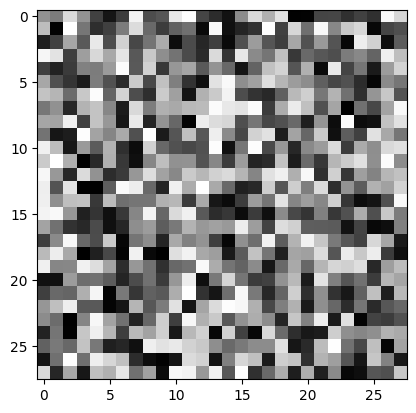

In [4]:
plt.imshow(second_image, cmap='gray')
plt.show()

In [5]:
A = torch.tensor([[1, 1], [1, 0]], dtype=torch.float32)

print("A^1: \n", torch.matrix_power(A, 1))
print("A^2: \n", torch.matrix_power(A, 2))
print("A^3: \n", torch.matrix_power(A, 3))
print("A^4: \n", torch.matrix_power(A, 4))

A^1: 
 tensor([[1., 1.],
        [1., 0.]])
A^2: 
 tensor([[2., 1.],
        [1., 1.]])
A^3: 
 tensor([[3., 2.],
        [2., 1.]])
A^4: 
 tensor([[5., 3.],
        [3., 2.]])


In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.hidden_layer = nn.Linear(input_size, 64) # 64 is output size
        self.activation = nn.ReLU()
        self.output_layer = nn.Linear(64, 2) # 64 is input, 2 is output size

    def forward(self, x):
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [7]:
model = MLP(input_size = 10)
print(model)

MLP(
  (hidden_layer): Linear(in_features=10, out_features=64, bias=True)
  (activation): ReLU()
  (output_layer): Linear(in_features=64, out_features=2, bias=True)
)


In [8]:
input_vecctor = torch.randn(10)
output = model(input_vecctor)
print(output)

tensor([-0.3544,  0.0053], grad_fn=<ViewBackward0>)


In [10]:
cross_entropy_loss = nn.CrossEntropyLoss()

# 0 for classification 1, 1 for classification 2
# kept classification2 as a target
target = torch.tensor([1])

# predicted for target to be classification1 is 2.0, and classification2 is 5.0
predicted1 = torch.tensor([[2.0, 5.0]])
loss1 = cross_entropy_loss(predicted1, target)
# As it predicted classification2 to be high, the loss will be less, because it is classification2
print(f'Loss when prediction is more likely a classification 1, {loss1.item():.4f}')

# predicted chances for classification1 to be 1.5 and for classification2 to be 1.1
# basically it predicted, chances for target to be classification1 is higher
predicted2 = torch.tensor([1.5, 1.1])
loss2 = cross_entropy_loss(predicted2, target)
# since it predicted wrong, the loss will be higher
print(f'Loss when prediction is more likely a classification 2, {loss2.item():.4f}')



Loss when prediction is more likely a classification 1, 0.0486
Loss when prediction is more likely a classification 2, 0.9130


In [12]:
mse_loss = nn.MSELoss()

predicted_price = torch.tensor([320000.0])
actual_price = torch.tensor([319999.0])

loss = mse_loss(predicted_price, actual_price)

print(f'MSE loss: {loss.item()}')

MSE loss: 1.0


In [13]:
from torch.optim import SGD, Adam

optimizer_sgd = SGD(model.parameters(), lr = 0.01, momentum = 0.9)

optimizer_adam = Adam(model.parameters(), lr = 0.01)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class NumberProductDataset(Dataset):
    def __init__(self, data_range):
        self.data = [(i, i + 1, i * ( i + 1)) for i in range(data_range)]

    def __getitem